# Notebook 3 : LSTM 

Cell 1 : Imports 

In [10]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
os.makedirs("../data/models", exist_ok=True)

TensorFlow version: 2.21.0


Cell 2 : Loading multi-year data

In [11]:
df_all = pd.read_csv("../data/raw/all_years_data.csv")

print("Shape:", df_all.shape)
print("Years available:", sorted(df_all["year"].unique()))
print("Sample countries:", df_all["country_name"].unique()[:8].tolist())

Shape: (2349, 11)
Years available: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Sample countries: ['Aruba', 'Africa Eastern and Southern', 'Afghanistan', 'Africa Western and Central', 'Angola', 'Albania', 'Andorra', 'Arab World']


Cell 3 : Rebuilding features on the full time series

In [12]:
FEATURES = [
    "gdp_per_capita",
    "energy_kwh_per_capita",
    "renewable_pct",
    "water_stress_pct",
    "population"
]

np.random.seed(42)

def compute_ai_index(row):
    gdp_score    = min((row.get("gdp_per_capita")    or 0) / 60000, 1.0)
    energy_score = min((row.get("energy_kwh_per_capita") or 0) / 15000, 1.0)
    ai_leaders = {"USA":1.0,"CHN":0.9,"GBR":0.7,"DEU":0.65,
                  "IND":0.55,"JPN":0.7,"CAN":0.65,"FRA":0.6,
                  "KOR":0.7,"ISR":0.65,"SGP":0.75,"AUS":0.6}
    boost = ai_leaders.get(row["country_code"], 0.0)
    base  = gdp_score*0.4 + energy_score*0.3 + boost*0.3
    return float(np.clip(base + np.random.normal(0, 0.03), 0, 1))

def compute_sustain_score(row):
    co2 = row.get("co2_per_capita", None)
    if pd.isna(co2) or co2 is None:
        energy = row.get("energy_kwh_per_capita", 5000) or 5000
        co2 = max(0.5, energy / 3000)
    renew = row.get("renewable_pct", 20) or 20
    water = row.get("water_stress_pct", 30) or 30
    co2_score   = max(0, 1 - co2 / 20)
    renew_score = renew / 100
    water_score = max(0, 1 - water / 100)
    return round((co2_score*0.4 + renew_score*0.4 + water_score*0.2) * 100, 2)

df_all["ai_expansion_index"]  = df_all.apply(compute_ai_index, axis=1)
df_all["sustainability_score"] = df_all.apply(compute_sustain_score, axis=1)

# Fill NaNs per column with median
for col in FEATURES:
    df_all[col] = df_all[col].fillna(df_all[col].median())

print("Features built. Shape:", df_all.shape)

Features built. Shape: (2349, 11)


Cell 4 : Building sequences for LSTM

In [13]:
SEQ_LEN   = 5    # use 5 years of history to predict the next year
ALL_FEATS = FEATURES + ["ai_expansion_index"]

def build_sequences(group):
    """For one country, slide a window of SEQ_LEN years → next year target."""
    group = group.sort_values("year").reset_index(drop=True)
    X_seqs, y_seqs = [], []
    for i in range(len(group) - SEQ_LEN):
        x_window = group[ALL_FEATS].iloc[i:i+SEQ_LEN].values
        y_target = group["sustainability_score"].iloc[i+SEQ_LEN]
        if not np.any(np.isnan(x_window)) and not np.isnan(y_target):
            X_seqs.append(x_window)
            y_seqs.append(y_target)
    return X_seqs, y_seqs

X_list, y_list = [], []
for _, grp in df_all.groupby("country_code"):
    xs, ys = build_sequences(grp)
    X_list.extend(xs)
    y_list.extend(ys)

X_seq = np.array(X_list, dtype=np.float32)
y_seq = np.array(y_list, dtype=np.float32)

print(f"Sequences built — X: {X_seq.shape}, y: {y_seq.shape}")
print(f"Each sample: {SEQ_LEN} years × {len(ALL_FEATS)} features → 1 target")

Sequences built — X: (336, 5, 6), y: (336,)
Each sample: 5 years × 6 features → 1 target


Cell 5 : Normalisation 

In [14]:
from sklearn.preprocessing import MinMaxScaler

n_samples, n_steps, n_feats = X_seq.shape

# Flatten to 2D to fit scaler, then reshape back
X_flat = X_seq.reshape(-1, n_feats)
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_flat).reshape(n_samples, n_steps, n_feats)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y_seq.reshape(-1, 1)).flatten()

# Train/test split (time-aware: last 20% of rows)
split = int(0.8 * n_samples)
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

print(f"Train: {X_train.shape}  Test: {X_test.shape}")

# Save scalers — the API needs these to transform incoming data
with open("../data/models/scaler_X.pkl", "wb") as f:
    pickle.dump(scaler_X, f)
with open("../data/models/scaler_y.pkl", "wb") as f:
    pickle.dump(scaler_y, f)
print("Scalers saved")

Train: (268, 5, 6)  Test: (68, 5, 6)
Scalers saved


Cell 6 : Building and training LSTM

In [15]:
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(n_steps, n_feats)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model_lstm.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_lstm.summary()

early_stop = EarlyStopping(monitor="val_loss", patience=10,
                            restore_best_weights=True)

history = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("LSTM training complete")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 5, 64)          │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - loss: 0.3179 - mae: 0.5236 - val_loss: 0.2461 - val_mae: 0.4531
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1566 - mae: 0.3582 - val_loss: 0.0666 - val_mae: 0.2389
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0567 - mae: 0.1896 - val_loss: 0.0283 - val_mae: 0.1130
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0395 - mae: 0.1413 - val_loss: 0.0104 - val_mae: 0.0788
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0219 - mae: 0.1203 - val_loss: 0.0091 - val_mae: 0.0734
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0190 - mae: 0.1081 - val_loss: 0.0086 - val_mae: 0.0769
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0173 - mae: 0.1016 - val_loss: 0.0064 - val_mae: 0.0633
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0152 - mae: 0.0964 - val_loss: 0.0059 - val_mae: 0.0560
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0139 - mae:

Cell 7 : Evaluating

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
LSTM MAE : 4.49
LSTM R²  : 0.9396


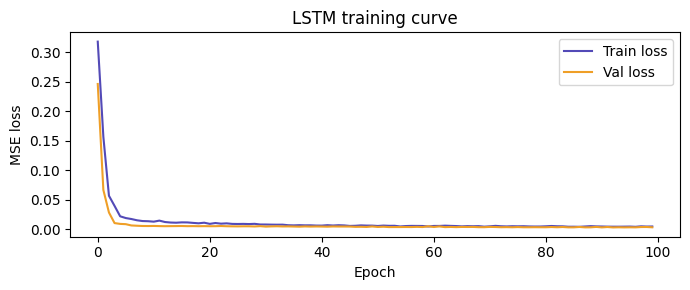

In [16]:
y_pred_scaled = model_lstm.predict(X_test).flatten()

# Inverse transform back to original score range
y_pred_actual = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()
y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten()

from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2  = r2_score(y_test_actual, y_pred_actual)
print(f"LSTM MAE : {mae:.2f}")
print(f"LSTM R²  : {r2:.4f}")

# Loss curve
plt.figure(figsize=(7,3))
plt.plot(history.history["loss"],     label="Train loss", color="#534AB7")
plt.plot(history.history["val_loss"], label="Val loss",   color="#EF9F27")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("LSTM training curve")
plt.legend()
plt.tight_layout()
plt.savefig("../data/processed/lstm_loss.png", dpi=120)
plt.show()

Cell 8 : Forecast 2024-2040 for every country

In [17]:
FORECAST_YEARS = list(range(2024, 2041))

def forecast_country(country_code, df_src, n_years=17):
    grp = df_src[df_src["country_code"] == country_code].sort_values("year")
    if len(grp) < SEQ_LEN:
        return None

    # Seed with the last SEQ_LEN real rows (shape: SEQ_LEN × n_feats)
    seed = grp[ALL_FEATS].tail(SEQ_LEN).values.astype(np.float32)
    forecasts = []

    for yr_offset in range(n_years):
        # Scale each row individually (scaler expects n_feats columns, not flattened)
        seed_scaled = scaler_X.transform(seed)          # shape: SEQ_LEN × n_feats
        window_scaled = seed_scaled.reshape(1, SEQ_LEN, n_feats)

        pred_scaled = model_lstm.predict(window_scaled, verbose=0)[0][0]
        pred_score  = float(scaler_y.inverse_transform([[pred_scaled]])[0][0])
        pred_score  = float(np.clip(pred_score, 0, 100))
        forecasts.append({"year": 2024 + yr_offset, "predicted_score": round(pred_score, 2)})

        # Build next synthetic row by nudging the last real row
        next_row = seed[-1].copy()
        next_row[0] *= 1.02                          # gdp_per_capita +2%/yr
        next_row[1] *= 1.015                         # energy_kwh_per_capita +1.5%/yr
        next_row[2]  = min(100, next_row[2] + 0.5)  # renewable_pct +0.5pp/yr
        next_row[3]  = min(100, next_row[3] * 1.01) # water_stress_pct +1%/yr
        next_row[4] *= 1.005                         # population +0.5%/yr
        next_row[5]  = min(1.0, next_row[5] + 0.03) # ai_expansion_index +3%/yr

        # Slide window forward
        seed = np.vstack([seed[1:], next_row])

    return forecasts

# Run for all countries
all_forecasts = []
countries_done = 0

for code in df_all["country_code"].unique():
    result = forecast_country(code, df_all)
    if result:
        name = df_all[df_all["country_code"] == code]["country_name"].iloc[0]
        for r in result:
            r["country_code"] = code
            r["country_name"] = name
        all_forecasts.extend(result)
        countries_done += 1

df_forecast = pd.DataFrame(all_forecasts)
df_forecast.to_csv("../data/processed/forecast_2024_2040.csv", index=False)
print(f"Forecast done for {countries_done} countries")
print(df_forecast[df_forecast["country_code"] == "IND"].head(10))

Forecast done for 261 countries
      year  predicted_score country_code country_name
1836  2024            67.48          IND        India
1837  2025            66.11          IND        India
1838  2026            63.27          IND        India
1839  2027            59.58          IND        India
1840  2028            59.84          IND        India
1841  2029            60.20          IND        India
1842  2030            60.57          IND        India
1843  2031            60.96          IND        India
1844  2032            61.34          IND        India
1845  2033            61.73          IND        India


Cell 9 : Plotting sample forecasts

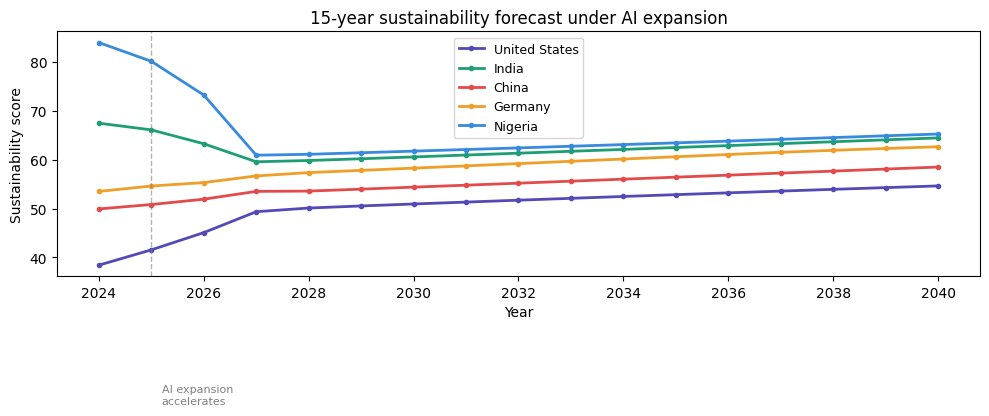

In [18]:
sample_countries = ["USA", "IND", "CHN", "DEU", "NGA"]
colors = ["#534AB7", "#1D9E75", "#E24B4A", "#EF9F27", "#378ADD"]

plt.figure(figsize=(10, 5))
for code, color in zip(sample_countries, colors):
    sub = df_forecast[df_forecast["country_code"] == code]
    if not sub.empty:
        name = sub["country_name"].iloc[0]
        plt.plot(sub["year"], sub["predicted_score"],
                 label=name, color=color, lw=2, marker="o", markersize=3)

plt.axvline(x=2025, color="gray", linestyle="--", lw=1, alpha=0.6)
plt.text(2025.2, 10, "AI expansion\naccelerates", fontsize=8, color="gray")
plt.xlabel("Year")
plt.ylabel("Sustainability score")
plt.title("15-year sustainability forecast under AI expansion")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../data/processed/forecast_plot.png", dpi=120)
plt.show()

Cell 10 : Saving LSTM model

In [19]:
model_lstm.save("../data/models/lstm_model.keras")

# Verify all model files exist
for fname in ["xgb_model.pkl", "lstm_model.keras",
              "scaler_X.pkl", "scaler_y.pkl",
              "feature_list.pkl"]:
    path = f"../data/models/{fname}"
    exists = os.path.exists(path)
    size   = os.path.getsize(path) // 1024 if exists else 0
    print(f"{'OK' if exists else 'MISSING':6} {fname:30} {size} KB")

OK     xgb_model.pkl                  552 KB
OK     lstm_model.keras               405 KB
OK     scaler_X.pkl                   0 KB
OK     scaler_y.pkl                   0 KB
OK     feature_list.pkl               0 KB
